# Data-Loader 

In [ ]:
import os
from pathlib import Path
import gzip 
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import torchvision.transforms.functional as F
import random

import torch

## Data filtration (chest left cam only with 3 modalities)

*Will do that later because need to connect to google cloud somehow without downloading everything. (maybe script to ls all the id training session and select only teh good ones and maybe this is not too heavy to download?)*

We'll only use left view (bc only one with dense depth)  and chest cam data (to start bc more for our app).So data loader must iterate over the training id session list one by one either real or synthetic and keep:
- id/camera_chest/left/depth_maps
- id/camera_chest/left/segmentation_masks
- id/camera_chest/left/video_frames

<br>And keep only id where there is the 3

## Semantic segmentation 

Input : mask in png sizes are W: 2208 H: 1242 or W: 1920 H: 1080 mode: RGB dtype: uint8 for real and synthetic (mostly 2208*1242 i think) 
R value = semantic class cf in *labelmap.json* , G/B values instance for panoptic i think, so IDC. 

1. 31 classes into 5 classes + ignore 
2. Resize to have closest to 480 in H (with nearest neighbors?) 
3. Crop to have 480*480 

Output : mask is 480*480 pixels with each pixel be in either 5 classes or ignored 

Final output

shape: 480 x 480
dtype: integer label map
values in {0,1,2,3,4,255} for example

Not one-hot.
For PyTorch segmentation loss, usually keep it as:

torch.LongTensor(H, W)

with ignore_index=255 in the loss. ex : nn.CrossEntropyLoss(ignore_index=255)

Seg dir exists: True
first seg files: ['000000.png', '000001.png', '000002.png', '000003.png', '000004.png']
Mask size: (2208, 1242)
Mask mode: L


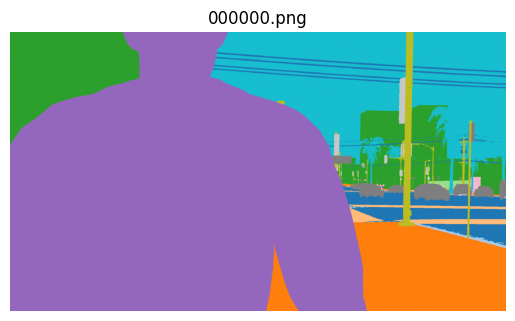

In [14]:
#Load mask png files and keep only red channel 
root = Path("/Users/user/Desktop/Thesis/master-thesis/SANPO Dataset Test/sanpo-synthetic/fde08012cbbe1e9d4013ba36ed99143b867ff3b14e4e0e87bfd51b238983cc10/fde08012cbbe1e9d4013ba36ed99143b867ff3b14e4e0e87bfd51b238983cc10/camera_chest/left")
seg_dir = root / "segmentation_masks"
seg_files = sorted(seg_dir.iterdir())

print("Seg dir exists:", seg_dir.exists())
print("first seg files:", [f.name for f in seg_files[:5]])

mask = Image.open(seg_files[0])
print("Mask size:", mask.size)
print("Mask mode:", mask.mode) #L means grayscal, 1 channel, all pixel has 1 value [0-255]

plt.imshow(mask, cmap='tab20')
plt.title(seg_files[0].name)
plt.axis('off')
plt.show()    


Values in mask: [[ 7  7  7 ... 27 27 27]
 [ 7  7  7 ... 27 27 27]
 [ 7  7  7 ... 27 27 27]
 ...
 [12 12 12 ...  3  3  3]
 [12 12 12 ...  3  3  3]
 [12 12 12 ...  3  3  3]]
Unique values in mask: [ 0  1  2  3  5  7  8 12 20 21 22 23 24 26 27 28 30]
Unique values in remapped mask: [  0   1   2   3   4 255]
Values in remapped mask: [[255 255 255 ... 255 255 255]
 [255 255 255 ... 255 255 255]
 [255 255 255 ... 255 255 255]
 ...
 [255 255 255 ...   0   0   0]
 [255 255 255 ...   0   0   0]
 [255 255 255 ...   0   0   0]]


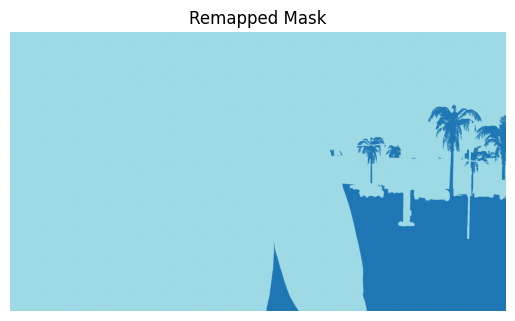

In [22]:
#See tha raw map and remap into my 5 classes and ignore the rest
mask_array = np.array(mask)
print("Values in mask:", mask_array)

print("Unique values in mask:", np.unique(mask_array))

# Define a mapping from original values to new class labels
IGNORE = 255

SIDEWALK = 0
ROAD = 1
CROSSWALK = 2
CURB = 3
TERRAIN = 4

lut = np.full(256, IGNORE, dtype=np.uint8)  # Initialize all to IGNORE
lut[3] = SIDEWALK #sidewalk 
lut[6] = SIDEWALK #paved trail 
lut[17] = SIDEWALK #other walkable

lut[1] = ROAD

lut[5] = CROSSWALK

lut[2] = CURB
lut[15] = CURB #stairs 

terrain_ids = [16, 18, 19, 28, 29, 30] #water body, inaccesible surface, railway track, tree, vegetation, terrain 
for i in terrain_ids:
    lut[i] = TERRAIN

#all the rest will be ignore 255 in the lut : 0 - unlabeled - 4 guard rail/road barrier - 7 building - 8 wall/fence - 9 hand rail - 10 opening-door - 11 opening-gate - 12 pedestrian - 13 rider - 14 animal - 20 obstacle - 21 vehicle - 22 traffic sign - 23 traffic light - 24 pole - 25 bus stop - 26 bike rack - 27 sky

# Apply the LUT to remap the mask values
remapped_mask = lut[mask_array] 
print("Unique values in remapped mask:", np.unique(remapped_mask))
print("Values in remapped mask:", remapped_mask)
plt.imshow(remapped_mask, cmap='tab20')
plt.title("Remapped Mask")
plt.axis('off')
plt.show()

Original size: (1242, 2208)
New size: (480, 853)
Resized mask size: (853, 480)
Resized mask mode: L


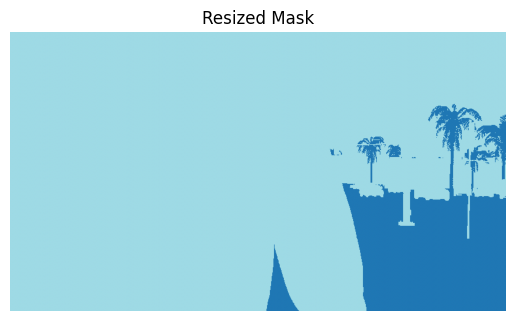

In [ ]:
#---------TO MODIFY: RESIZE THE MASK WITH DEPTH AND FRAME COMMON FUNCTION----------------

#Resize the remapped mask with nearest neighbor interpolation to 480*480 to match the input size of the model
H = remapped_mask.shape[0]
W = remapped_mask.shape[1]

scale = 480 / H
new_h = 480
new_w = round(W * scale) 

print("Original size:", (H, W))
print("New size:", (new_h, new_w))

resized_mask = Image.fromarray(remapped_mask).resize((new_w, new_h), resample=Image.NEAREST) #Use nearest neighbor interpolation to preserve class labels
print("Resized mask size:", resized_mask.size)
print("Resized mask mode:", resized_mask.mode)
plt.imshow(resized_mask, cmap='tab20')
plt.title("Resized Mask")
plt.axis('off')
plt.show()


## Frame image RGB 

1. Resize and crop with the 2 other modalities 
2. Normalize ? or before ? 

Frame dir exists: True
first frame files: ['000000.png', '000001.png', '000002.png', '000003.png', '000004.png']
Frame size: (2208, 1242)
Frame mode: RGB


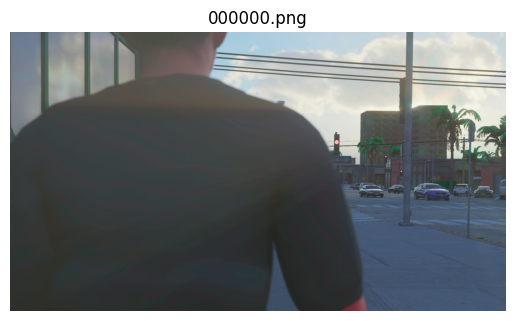

In [29]:
#Load frame png files and see the size and mode
frame_dir = root / "video_frames" 
frame_files = sorted(frame_dir.iterdir())
print("Frame dir exists:", frame_dir.exists())
print("first frame files:", [f.name for f in frame_files[:5]])
frame = Image.open(frame_files[0])  #frame is RGB, 3 channels 

print("Frame size:", frame.size)
print("Frame mode:", frame.mode)
plt.imshow(frame)
plt.title(frame_files[0].name)
plt.axis('off')
plt.show()

## Dense Depth map 

Is a float16 buffer zipped in .gz files. 

Real data : range 0-80 meters res 1280*720 

Synthetic data :  unit weird ?? 0.536 - 46100.0 on an image ? res : 2208*1080 

1. load unzip and put in np array 
2. crop and resize with bilinear aligned with 2 other modalities 
3. unify units (meters) 

### Function to resize and crop image, depth AND seg to 480*480

In [ ]:
#resize and crop mask, depth and image together to 480x480

def resize_and_crop(image, mask, depth, size=480):
    # Resize: shortest side = 480
    image = F.resize(image, size, interpolation=F.InterpolationMode.BILINEAR) #Use bilinear interpolation for image to preserve the visual quality
    mask  = F.resize(mask,  size, interpolation=F.InterpolationMode.NEAREST) #Use nearest neighbor interpolation to preserve class labels
    depth = F.resize(depth, size, interpolation=F.InterpolationMode.BILINEAR) #Use bilinear interpolation for depth map to preserve the continuous values

    # Get new size
    w, h = image.size

    # Random crop (train)
    i = random.randint(0, h - size)
    j = random.randint(0, w - size)

    image = F.crop(image, i, j, size, size)
    mask  = F.crop(mask,  i, j, size, size)
    depth = F.crop(depth, i, j, size, size)

    # For validation and test, use center crop
    # image = F.center_crop(image, 480)
    # mask  = F.center_crop(mask, 480)
    # depth = F.center_crop(depth, 480)

    return image, mask, depth